### Anomaly detection of MNIST images using Convolutional Autoencoder Neural Net Solution
- Implementing a Convolutional Autoencoder (CAE) for anomaly detection on the MNIST dataset involves training the model exclusively on "normal" data (e.g., specific digits or clean images)
- So that it fails to accurately reconstruct "anomalous" data (e.g., different digits or noisy images).

#### Imports

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np # For numerical operations
import struct # To read the binary file format of the dataset
# from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd
import os
import struct
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Tuple, List, Any, Optional
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, recall_score, precision_score
import seaborn as sns
from pathlib import Path
from timeit import default_timer as timer


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ADE\miniconda3\envs\ai-thursdays-env\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\ADE\miniconda3\envs\ai-thursdays-env\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\ADE\miniconda3\envs\ai-thursdays-env\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start
    self

#### Specify the configuration

In [ ]:
import torch

WORKING_FOLDER_PATH = "."

class Config:
    line_divider = "=" * 50
    next_line = "\n"
    random_state = 100
    train_if_missing = True
    
    img_width = 28
    img_height = 28
    n_out_features = 256
    first_layer_conv_width = 3
    first_layer_conv_height = 3
    dense_layer_size = 100
    epochs = 6
    batch_size = 64
    learning_rate = 0.001
    dropout_rate = 0.5
    n_classes = 10
    
    # Convolutional layer parameters
    in_channels_layer_1 = 1
    out_channels_layer_1 = 32
    in_channels_layer_2 = 32
    out_channels_layer_2 = 64
    in_channels_layer_3 = 64
    out_channels_layer_3 = 128    
    kernel_size_cnn = 3
    kernel_size_maxpool = 2
    padding = 1
    num_filters = 16
    
    hidden_dim = 250
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_fraction_split = 0.6
    
    # Data paths
    train_images_path = f"{WORKING_FOLDER_PATH}/data/minst-image-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte"
    train_labels_path = f"{WORKING_FOLDER_PATH}/data/minst-image-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte"
    test_images_path = f"{WORKING_FOLDER_PATH}/data/minst-image-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte"
    test_labels_path = f"{WORKING_FOLDER_PATH}/data/minst-image-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte"

    # Model path
    model_cnn_path = f"{WORKING_FOLDER_PATH}/models/mnist_cnn_model.pth"
    

    is_use_pretrained_model = True

config = Config()

#### MNIST IDX Reader (Raw File Loader)

In [10]:
class MNISTLoader:
    @staticmethod
    def load_images(filepath: str) -> np.ndarray:
        with open(filepath, 'rb') as f:
            magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.frombuffer(f.read(), dtype=np.uint8)
            images = images.reshape(num, 1, rows, cols)
        return images

    @staticmethod
    def load_labels(filepath: str) -> np.ndarray:
        with open(filepath, 'rb') as f:
            magic, num = struct.unpack(">II", f.read(8))
            labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels
    
    @staticmethod
    def load_data(config: Config) -> Tuple[np.ndarray, ...]:
        try:
            # Load the data
            print(f"x_train path: {config.train_images_path}")
            print(f"x_test path: {config.test_images_path}")
            print(f"y_train path: {config.train_labels_path}")
            print(f"y_test path: {config.test_labels_path}")
            
            x_train = MNISTLoader.load_images(config.train_images_path)
            y_train = MNISTLoader.load_labels(config.train_labels_path)
            x_test = MNISTLoader.load_images(config.test_images_path)
            y_test = MNISTLoader.load_labels(config.test_labels_path)

            normal_idx  = [i for i, label in enumerate(y_train) if label == 0]
            x_train_normal = x_train[normal_idx]
            y_train_normal = y_train[normal_idx]

            
            print("Data loaded successfully!")
            print(f"Training Data Shape: {x_train_normal.shape}")
            print(f"Training Labels Shape: {y_train_normal.shape}")
            print(f"Test Data Shape: {x_test.shape}")
            print(f"Test Labels Shape: {y_test.shape}")
            
        except FileNotFoundError:
            print("Error: Files not found. Please check if the dataset is added to the notebook correctly.")
            return None, None, None, None   
            raise e
        return (x_train_normal, y_train_normal, x_test, y_test) 
    
x_train, y_train, x_test, y_test = MNISTLoader.load_data(config)

x_train path: ./data/minst-image-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte
x_test path: ./data/minst-image-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
y_train path: ./data/minst-image-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte
y_test path: ./data/minst-image-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
Data loaded successfully!
Training Data Shape: (5923, 1, 28, 28)
Training Labels Shape: (5923,)
Test Data Shape: (10000, 1, 28, 28)
Test Labels Shape: (10000,)


#### Let us sample some of the digit images

In [12]:
def sample_mnist_images(
        n_samples: int=10, 
        images: np.ndarray=x_train, 
        labels: np.ndarray=y_train) -> None:
    """ 
    Sample and visualize a few images from the MNIST dataset.
    :param n_samples: Number of samples to visualize
    :param images: Array of images to sample from (default is x_train)
    :param labels: Array of labels corresponding to the images (default is y_train)
    """
    plt.figure(figsize=(10, 4))
    for i in range(n_samples):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()



##### Sample of normal images i.e. the training dataset

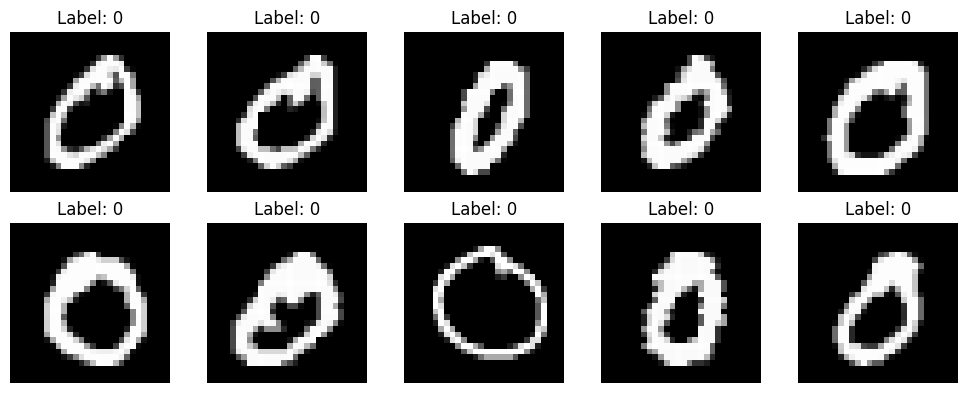

In [13]:
sample_mnist_images()

##### Sample of test dataset images i.e. combination of "normal" and "anomalous" images

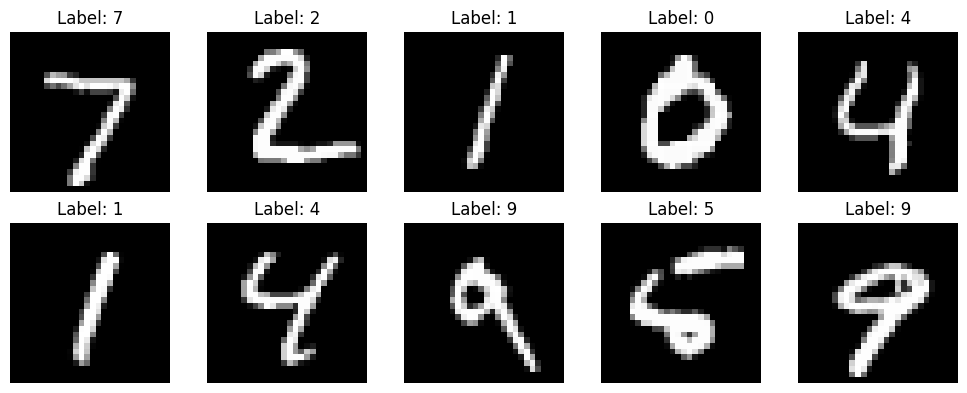

In [14]:
sample_mnist_images(images=x_test, labels=y_test)   


#### Define Convolutional Autoencoder

In [15]:
class CAE(nn.Module):
    def __init__(self):
        super(CAE, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), # [16, 14, 14]
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # [32, 7, 7]
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = CAE().to(config.device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)


#### Custom Dataset Class

In [16]:
class MNISTDataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray):
        self.images = torch.tensor(images, dtype=torch.float32) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

#### Create Dataloader for the train/validation/unseen datasets

In [ ]:
train_dataset = MNISTDataset(x_train, y_train)
test_dataset = MNISTDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False)


#### Define Convolutional Autoencoder

In [ ]:
class CAE(nn.Module):
    def __init__(self, config: Config):
        super(CAE, self).__init__()
        self.config = config
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), # [16, 14, 14]
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # [32, 7, 7]
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

#### Trainer Class (Train + Validation Loop)

In [ ]:
class Trainer:
    """
    Trainer class to handle the training and validation of the CNN model.
    """
    def __init__(
            self, 
            model: nn.Module, 
            train_loader: DataLoader, 
            config: Config):
        """ 
        Initializes the Trainer with the model, data loaders, and configuration.
        :param model: The neural network model to be trained.
        :param train_loader: DataLoader for the training dataset.
        :param config: Configuration object containing training parameters.
        """
        self.model = model.to(config.device)
        self.train_loader = train_loader
        self.device = config.device

        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

        self.history = []

    def train(self, epochs: int = 10):
        """
        Trains the model for a specified number of epochs, evaluating on the validation set after each epoch.
        :param epochs: Number of epochs to train the model.
        """
        for epoch in range(epochs):
            epoch_loss = 0
            for data, _ in self.train_loader:
                data = data.to(self.device)
                output = model(data)
                loss = self.criterion(output, data)
                
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / len(self.train_loader)
            self.history.append(avg_loss)
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

        # Loss Plot
        plt.plot(self.history)
        plt.title("Training Loss (Normal Class Only)")
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.show()

#### Performance Evaluation of the classifier

In [59]:
class PerformanceEvaluator:    
    @staticmethod
    def evaluate(
        model: Any, 
        loader: torch.utils.data.DataLoader, 
        config: Config,
        data_type: str="Unseen Data"
        ) -> Tuple[List[int], List[int]]:
        """
        Evaluates the model on the provided data loader and prints the classification report, weighted F1 score, and confusion matrix.
        :param model: The trained model to evaluate.
        :param loader: The data loader for the evaluation data.
        :param config: The configuration object containing device information.
        :param data_type: A string indicating the type of data being evaluated (e.g., "Unseen Data").
        """
        model.eval()

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in loader:
                images = images.to(config.device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().detach().tolist())
                all_labels.extend(labels.cpu().detach().tolist())
        
        print(f"Number of predictions: {len(all_preds)}")
        print(f"Number of labels: {len(all_labels)}")
        print(config.line_divider)

        print(f"\nClassification Report ({data_type})")
        print(classification_report(all_labels, all_preds))

        f1 = f1_score(all_labels, all_preds, average='weighted')
        print(f"Weighted F1 Score: {f1:.4f}")

        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix - {data_type}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        return all_preds, all_labels


#### Plot Training Curves

In [60]:
def plot_training_curves(trainer: Trainer):
    """
    Plots the training and validation loss and accuracy curves over epochs.
    :param trainer: The Trainer object containing the training history.    
    """
    epochs = range(1, len(trainer.train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, trainer.train_losses, label="Train Loss")
    plt.plot(epochs, trainer.val_losses, label="Val Loss")
    plt.legend()
    plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, trainer.train_acc, label="Train Acc")
    plt.plot(epochs, trainer.val_acc, label="Val Acc")
    plt.legend()
    plt.title("Accuracy")

    plt.show()

#### Create a model manager component
- It will e used to manage saving/loading of trained models 

In [61]:
class ModelManager:
    """
    Manages saving and loading of trained models.
    """
    def __init__(
            self, 
            model: nn.Module,            
            config: Config):
        self.model = model
        self.model_path = Path(config.model_cnn_path)
        self.device = config.device

    def exists(self) -> bool:
        """
        Checks if a saved model exists at the specified path.
        :return: True if the model file exists, False otherwise.
        """
        return self.model_path.exists()

    def save(self):
        """
        Saves the current model state to the specified path.
        """
        torch.save({
            "model_state_dict": self.model.state_dict()
        }, self.model_path)
        print(f"✅ Model saved to {self.model_path}")

    def load(self):
        """
        Loads the model state from the specified path and prepares it for evaluation.
        """
        checkpoint = torch.load(self.model_path, map_location=self.device)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.model.to(self.device)
        self.model.eval()
        print(f"✅ Model loaded from {self.model_path}")

#### Run the classier:
- run the train-validate cycle
- use the trained classifier to predict the class of unseen images 

Model initialized with architecture:
MnistCnn(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256

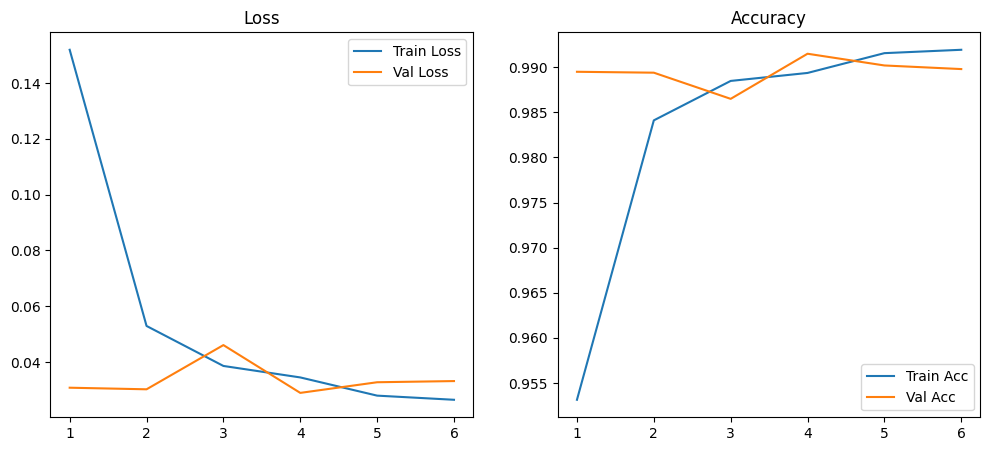


Evaluating on training and test data after training...
Number of predictions: 58800
Number of labels: 58800

Classification Report (Training Data)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5809
           1       1.00      1.00      1.00      6618
           2       1.00      1.00      1.00      5834
           3       1.00      1.00      1.00      6010
           4       1.00      0.99      1.00      5722
           5       1.00      0.99      0.99      5309
           6       1.00      0.98      0.99      5792
           7       1.00      0.99      1.00      6136
           8       0.97      1.00      0.99      5738
           9       0.99      1.00      0.99      5832

    accuracy                           0.99     58800
   macro avg       0.99      0.99      0.99     58800
weighted avg       0.99      0.99      0.99     58800

Weighted F1 Score: 0.9944


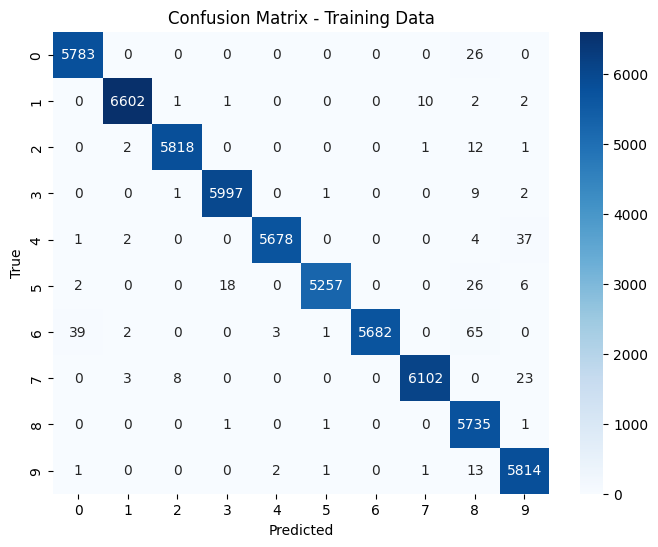



Number of predictions: 10000
Number of labels: 10000

Classification Report (Test Data)
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       1.00      1.00      1.00      1032
           3       0.98      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       1.00      0.98      0.99       892
           6       1.00      0.97      0.98       958
           7       0.99      0.99      0.99      1028
           8       0.97      1.00      0.98       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Weighted F1 Score: 0.9898


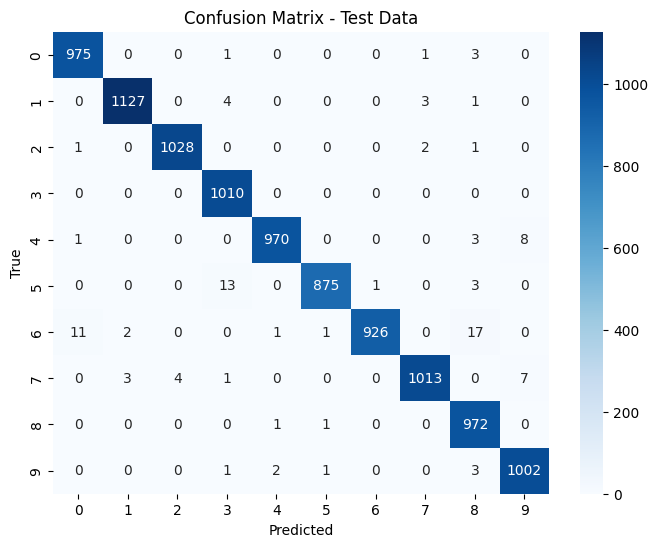

✅ Model saved to models\mnist_cnn_model.pth


Training/validation time taken:  1035.63 (secs) /  17.26 (mins)



In [62]:
def run_classifier():
    
    # ------------------------
    # Initialize Model
    # ------------------------
    start = timer()
    model = MnistCnn(config)
    print(f"Model initialized with architecture:\n{model}\n")
    print(config.line_divider)

    model_manager = ModelManager(model, config)

    # ------------------------
    # Load or Train
    # ------------------------
    if model_manager.exists():
        model_manager.load()
        print("Skipping training — using saved model.")
    else:
        if not config.train_if_missing:
            raise FileNotFoundError("Model not found and training disabled.")

        print("Training new model...")
        trainer = Trainer(model, train_loader, test_loader, config)
        trainer.train(epochs=config.epochs)
        plot_training_curves(trainer)
        print("\nEvaluating on training and test data after training...")
        PerformanceEvaluator.evaluate(model, train_loader, config, "Training Data")
        print("\n")
        PerformanceEvaluator.evaluate(model, test_loader, config, "Test Data")
        model_manager.save()

    end = timer()
    elapsed_time_seconds = end - start
    elapsed_time_mins = elapsed_time_seconds / 60
    print(f"\n\nTraining/validation time taken: {elapsed_time_seconds: .2f} (secs) / {elapsed_time_mins: .2f} (mins)")
    print(f"{config.line_divider}{config.next_line}")
    return model

model = run_classifier()


#### Check the classifier prediction results


Evaluating on unseen data...
Number of predictions: 1200
Number of labels: 1200

Classification Report (Unseen Data)
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       114
           1       0.99      0.99      0.99       124
           2       1.00      1.00      1.00       124
           3       0.99      1.00      1.00       121
           4       1.00      0.97      0.99       120
           5       0.99      0.96      0.98       112
           6       1.00      0.99      1.00       126
           7       0.99      0.99      0.99       129
           8       0.97      1.00      0.98       113
           9       0.97      0.99      0.98       117

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200

Weighted F1 Score: 0.9875


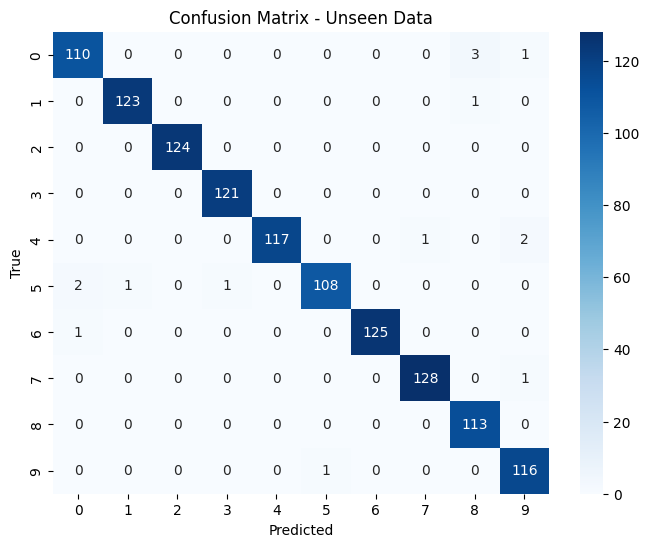



Displaying sample predictions on unseen data...


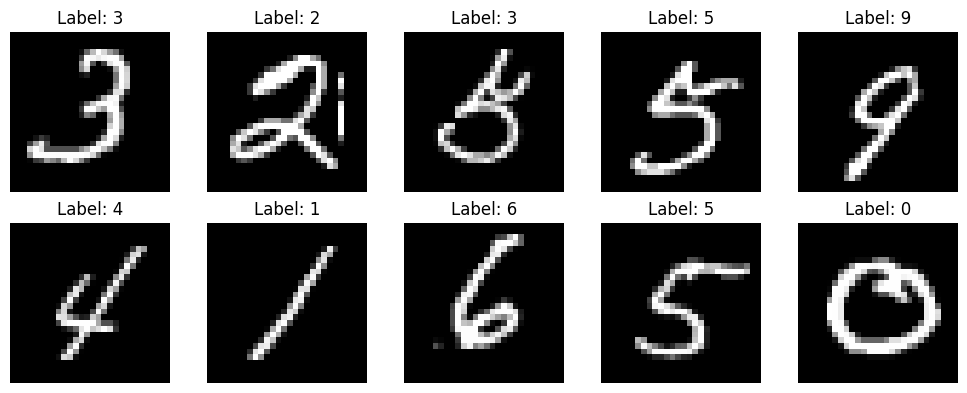

In [63]:

def compute_unseen_data_predictions():
    """
    Computes predictions on the unseen data and displays a sample of the predictions.
    """
    # ------------------------
    # Evaluate on Unseen Data
    # ------------------------
    print("\nEvaluating on unseen data...")
    predictions, labels = PerformanceEvaluator.evaluate(model, unseen_loader, config)
    print("\n\nDisplaying sample predictions on unseen data...")
    sample_mnist_images(10, x_unseen, np.array(predictions))

compute_unseen_data_predictions()